From many Diseases, Diabetes prediction is choosen

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [3]:
df = pd.read_csv("diabetes_prediction_dataset.csv.zip")

In [4]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df.shape

(100000, 9)

In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


Since all the values are notnull, we can proceed further

In [8]:
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])

df["smoking_history"] = le.fit_transform(df["smoking_history"])

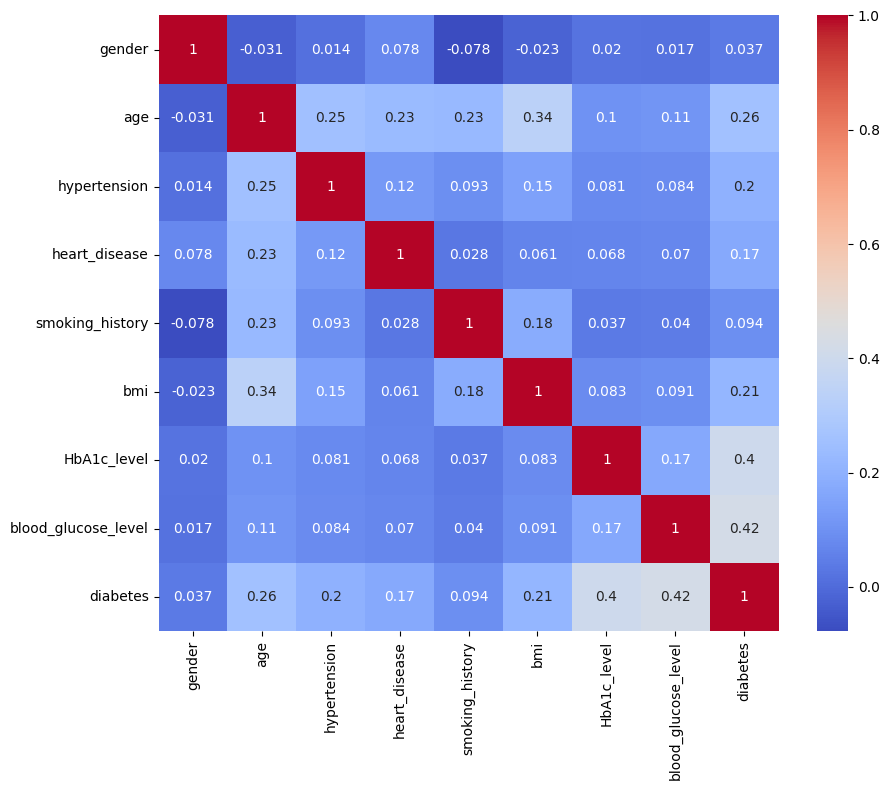

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.show()

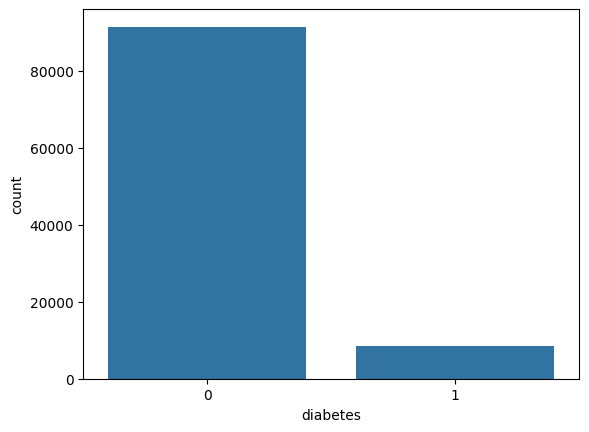

In [10]:
sns.countplot(x='diabetes',data=df)

plt.show()

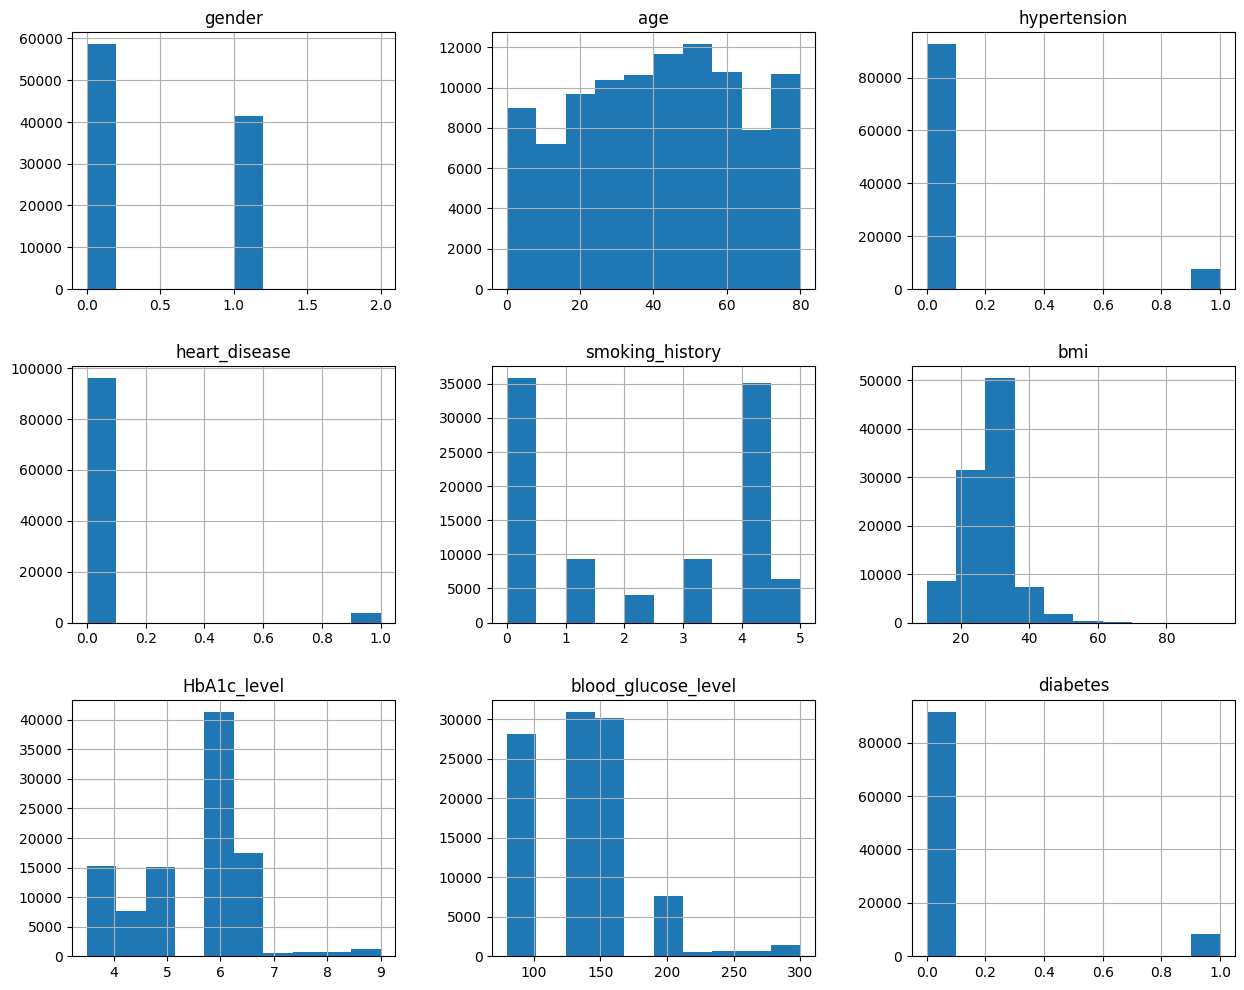

In [11]:
df.hist(figsize=(15,12))

plt.show()

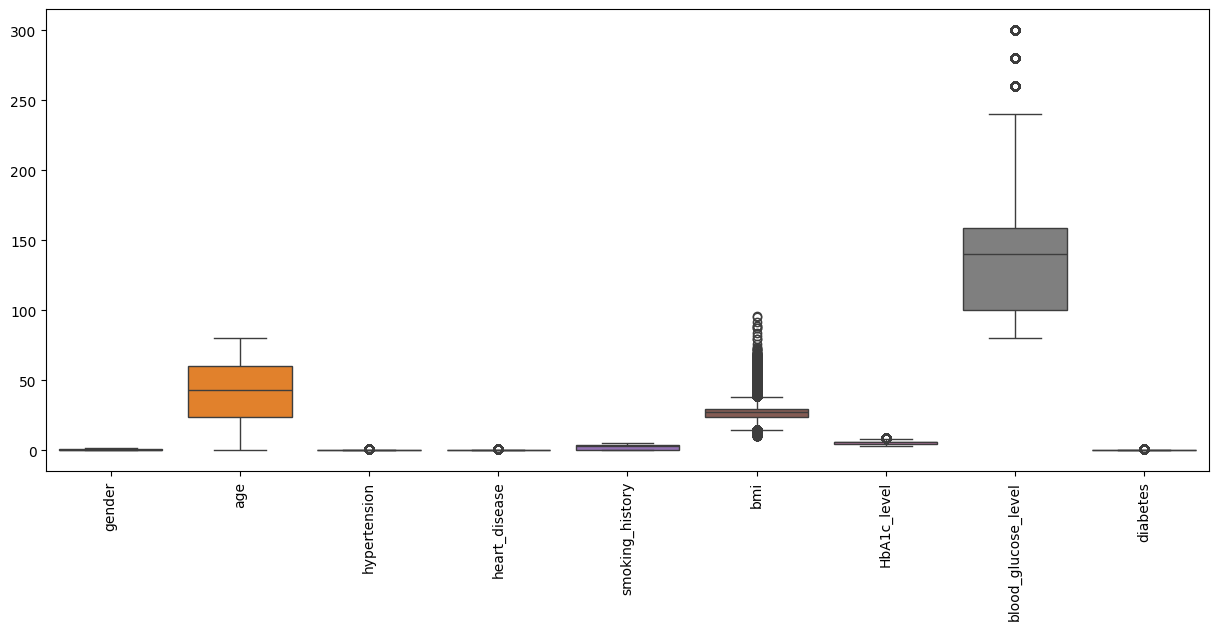

In [12]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

In [13]:
X = df.drop("diabetes",axis=1)

y = df["diabetes"]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_lr))

print(classification_report(y_test,pred_lr))

Accuracy: 0.95865
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.86      0.61      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [17]:
svm = SVC()

svm.fit(X_train,y_train)

pred_svm = svm.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_svm))

print(classification_report(y_test,pred_svm))

Accuracy: 0.96235
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18292
           1       0.98      0.57      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.97      0.79      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [18]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_rf))

print(classification_report(y_test,pred_rf))

Accuracy: 0.9707
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



In [19]:
xgb = XGBClassifier()

xgb.fit(X_train,y_train)

pred_xgb = xgb.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_xgb))

print(classification_report(y_test,pred_xgb))

Accuracy: 0.97125
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.70      0.81      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.85      0.90     20000
weighted avg       0.97      0.97      0.97     20000



In [20]:
models = ["Logistic Regression","SVM","Random Forest","XGBoost"]

accuracy = [

accuracy_score(y_test,pred_lr),

accuracy_score(y_test,pred_svm),

accuracy_score(y_test,pred_rf),

accuracy_score(y_test,pred_xgb)

]

comparison = pd.DataFrame({

"Model":models,

"Accuracy":accuracy

})

comparison

,Model,Accuracy
0,Logistic Regression,0.95865
1,SVM,0.96235
2,Random Forest,0.97070
3,XGBoost,0.97125


In [21]:
prob = rf.predict_proba(X_test)[:,1]

print("ROC AUC Score :",roc_auc_score(y_test,prob))

ROC AUC Score : 0.963292955520925


In [24]:
sample = pd.DataFrame({
    'gender': [1],
    'age': [45],
    'hypertension': [0],
    'heart_disease': [1],
    'smoking_history': [3],   # Use the encoded value from your dataset
    'bmi': [28.5],
    'HbA1c_level': [6.2],
    'blood_glucose_level': [150]
})

sample = scaler.transform(sample)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Patient is likely to have Diabetes.")
else:
    print("Patient is unlikely to have Diabetes.")

Patient is unlikely to have Diabetes.
